In [25]:
# 1. Import libraries

import warnings
warnings.filterwarnings("ignore")

import os
import urllib.request
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [26]:
!pip -q install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

# Load REAL UCI Student Performance Dataset
student_performance = fetch_ucirepo(id=320)

# Features and target
X_data = student_performance.data.features
y_data = student_performance.data.targets

# Combine into one dataframe
df = pd.concat([X_data, y_data], axis=1)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [27]:
# 4. Inspect and clean the dataset

print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicate records if any exist
df = df.drop_duplicates().reset_index(drop=True)

print("\nShape after cleaning:", df.shape)

Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardi

,missing_values
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0



Duplicate rows: 0

Shape after cleaning: (649, 33)


In [28]:
# 5. Create readable performance categories for the tracker

def grade_category(grade):
    if grade >= 16:
        return "Excellent"
    elif grade >= 14:
        return "Good"
    elif grade >= 10:
        return "Pass"
    else:
        return "At Risk"

df["performance_category"] = df["G3"].apply(grade_category)

display(df[["G1", "G2", "G3", "performance_category"]].head(10))
print("\nCategory counts:")
print(df["performance_category"].value_counts())

,G1,G2,G3,performance_category
0,0,11,11,Pass
1,9,11,11,Pass
2,12,13,12,Pass
3,14,14,14,Good
4,11,13,13,Pass
5,12,12,13,Pass
6,13,12,13,Pass
7,10,13,13,Pass
8,15,16,17,Excellent
9,12,12,13,Pass



Category counts:
performance_category
Pass         355
Good         112
At Risk      100
Excellent     82
Name: count, dtype: int64


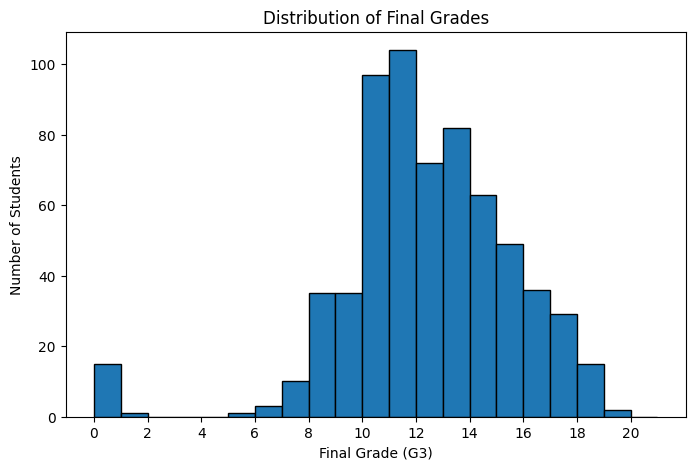

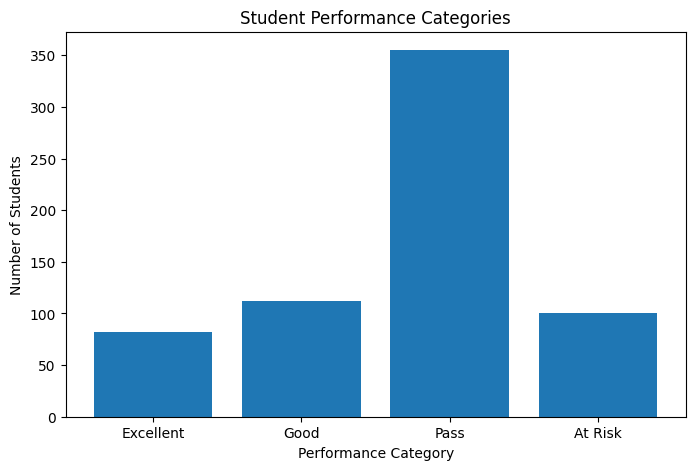

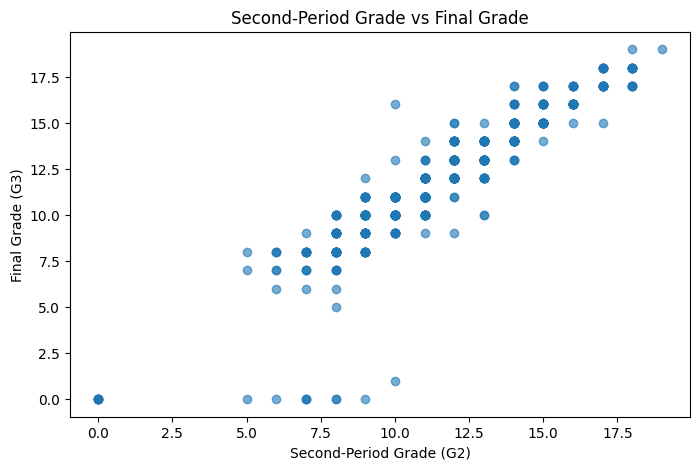

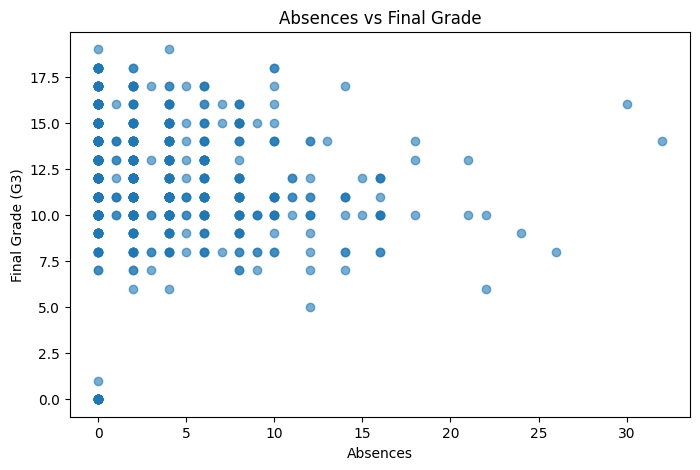

In [29]:
# 6. Exploratory Data Analysis

plt.figure(figsize=(8, 5))
plt.hist(df["G3"], bins=range(0, 22), edgecolor="black")
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.xticks(range(0, 21, 2))
plt.show()

category_order = ["Excellent", "Good", "Pass", "At Risk"]
category_counts = df["performance_category"].value_counts().reindex(
    category_order, fill_value=0
)

plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values)
plt.title("Student Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["G2"], df["G3"], alpha=0.6)
plt.title("Second-Period Grade vs Final Grade")
plt.xlabel("Second-Period Grade (G2)")
plt.ylabel("Final Grade (G3)")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["absences"], df["G3"], alpha=0.6)
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade (G3)")
plt.show()

,correlation_with_G3
G3,1.000000
G2,0.918548
G1,0.826387
studytime,0.249789
Medu,0.240151
Fedu,0.211800
famrel,0.063361
goout,-0.087641
absences,-0.091379
health,-0.098851


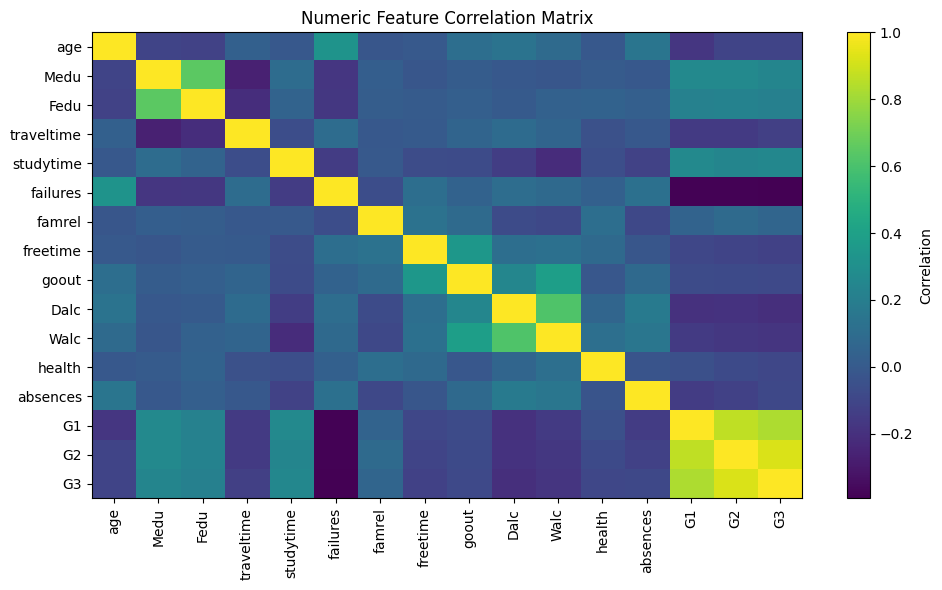

In [30]:
# 7. Correlation analysis for numeric columns

numeric_df = df.select_dtypes(include=np.number)
correlation_with_g3 = (
    numeric_df.corr()["G3"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_G3")
)

display(correlation_with_g3)

plt.figure(figsize=(10, 6))
plt.imshow(numeric_df.corr(), aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(numeric_df.columns)),
    numeric_df.columns,
    rotation=90
)
plt.yticks(
    range(len(numeric_df.columns)),
    numeric_df.columns
)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [31]:
# 8. Prepare features and target
# G1 and G2 are retained because a performance tracker can use past-term
# grades to predict the final result.

X = df.drop(columns=["G3", "performance_category"])
y = df["G3"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of input features:", X.shape[1])
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Number of input features: 32
Numeric features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Training records: 519
Testing records: 130


In [32]:
# 9. Build preprocessing pipeline

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [33]:
# 10. Train and compare multiple regression models

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_split=4,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    )
}

model_results = []
trained_models = {}

for model_name, algorithm in models.items():
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", algorithm)
    ])

    model_pipeline.fit(X_train, y_train)
    predictions = model_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    model_results.append({
        "Model": model_name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2 Score": round(r2, 3)
    })

    trained_models[model_name] = model_pipeline

results_df = pd.DataFrame(model_results).sort_values(
    "R2 Score",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.765,1.215,0.849
1,Ridge Regression,0.764,1.214,0.849
2,Random Forest,0.749,1.243,0.842
3,Gradient Boosting,0.755,1.272,0.834


In [34]:
# 11. Select and evaluate the best model

best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

test_predictions = best_model.predict(X_test)
test_predictions = np.clip(test_predictions, 0, 20)

mae = mean_absolute_error(y_test, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
r2 = r2_score(y_test, test_predictions)

print("Best model:", best_model_name)
print("Mean Absolute Error:", round(mae, 3))
print("Root Mean Squared Error:", round(rmse, 3))
print("R2 Score:", round(r2, 3))

Best model: Linear Regression
Mean Absolute Error: 0.765
Root Mean Squared Error: 1.215
R2 Score: 0.849


,Actual Grade,Predicted Grade,Actual Category,Predicted Category
0,19,18.40,Excellent,Excellent
1,12,11.83,Pass,Pass
2,18,18.56,Excellent,Excellent
3,11,10.81,Pass,Pass
4,11,11.74,Pass,Pass
5,17,16.52,Excellent,Excellent
6,18,17.69,Excellent,Excellent
7,8,9.21,At Risk,At Risk
8,10,10.99,Pass,Pass
9,11,10.53,Pass,Pass


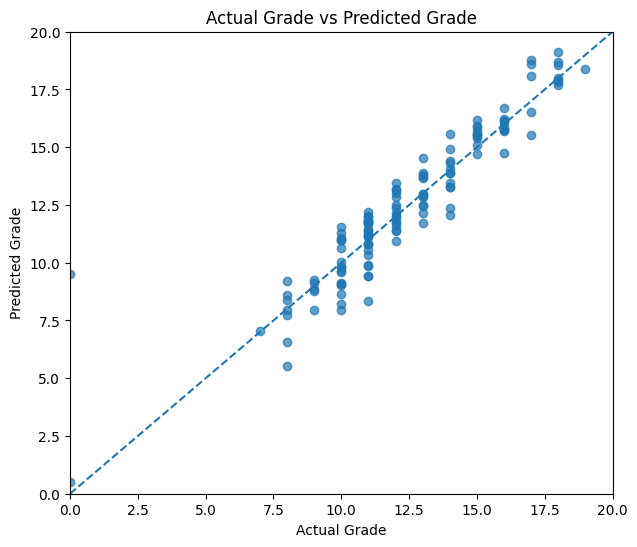

In [35]:
# 12. Actual vs predicted results

comparison_df = pd.DataFrame({
    "Actual Grade": y_test.values,
    "Predicted Grade": np.round(test_predictions, 2)
})

comparison_df["Actual Category"] = comparison_df["Actual Grade"].apply(
    grade_category
)
comparison_df["Predicted Category"] = comparison_df["Predicted Grade"].apply(
    grade_category
)

display(comparison_df.head(20))

plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_predictions, alpha=0.7)
plt.plot([0, 20], [0, 20], linestyle="--")
plt.title("Actual Grade vs Predicted Grade")
plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.show()

In [36]:
# 13. Five-fold cross-validation

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-validation R2 scores:", np.round(cv_scores, 3))
print("Average R2 score:", round(cv_scores.mean(), 3))

Cross-validation R2 scores: [0.753 0.74  0.821 0.855 0.801]
Average R2 score: 0.794


In [37]:
# 14. Feature importance
# This works directly for tree-based models.

model_step = best_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    feature_names = best_model.named_steps[
        "preprocessor"
    ].get_feature_names_out()

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_step.feature_importances_
    }).sort_values("Importance", ascending=False).head(15)

    display(importance_df)

    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df["Feature"][::-1],
        importance_df["Importance"][::-1]
    )
    plt.title("Top 15 Important Features")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(
        "The selected model does not provide tree-based feature importance."
    )

The selected model does not provide tree-based feature importance.


In [38]:
# 15. Predict performance for any new student

def predict_student(student_details):
    student_df = pd.DataFrame([student_details])

    # Arrange columns in exactly the same order as training data
    student_df = student_df[X.columns]

    predicted_grade = float(best_model.predict(student_df)[0])
    predicted_grade = round(max(0, min(20, predicted_grade)), 2)
    category = grade_category(predicted_grade)

    if category == "Excellent":
        suggestion = (
            "Excellent performance. Maintain the current study routine."
        )
    elif category == "Good":
        suggestion = (
            "Good performance. Regular revision can improve the final grade."
        )
    elif category == "Pass":
        suggestion = (
            "Passing performance. Increase revision and reduce absences."
        )
    else:
        suggestion = (
            "Student is at risk. Academic support and a structured study "
            "plan are recommended."
        )

    return {
        "Predicted Final Grade": predicted_grade,
        "Maximum Grade": 20,
        "Performance Category": category,
        "Suggestion": suggestion
    }

In [39]:
# 16. Example prediction using a real-format student record

example_student = X.iloc[0].to_dict()

# Change some values to test a different student
example_student["G1"] = 12
example_student["G2"] = 13
example_student["studytime"] = 2
example_student["failures"] = 0
example_student["absences"] = 4
example_student["internet"] = "yes"

prediction_result = predict_student(example_student)

print("Prediction result:")
for key, value in prediction_result.items():
    print(f"{key}: {value}")

Prediction result:
Predicted Final Grade: 13.12
Maximum Grade: 20
Performance Category: Pass
Suggestion: Passing performance. Increase revision and reduce absences.


In [40]:
# 17. Create a complete tracker report for the test students

tracker_report = X_test.copy().reset_index(drop=True)
tracker_report["actual_final_grade"] = y_test.reset_index(drop=True)
tracker_report["predicted_final_grade"] = np.round(test_predictions, 2)
tracker_report["predicted_category"] = tracker_report[
    "predicted_final_grade"
].apply(grade_category)

tracker_report["needs_intervention"] = np.where(
    tracker_report["predicted_final_grade"] < 10,
    "Yes",
    "No"
)

display(
    tracker_report[
        [
            "school",
            "sex",
            "age",
            "G1",
            "G2",
            "absences",
            "actual_final_grade",
            "predicted_final_grade",
            "predicted_category",
            "needs_intervention"
        ]
    ].head(20)
)

print(
    "Students predicted to need intervention:",
    (tracker_report["needs_intervention"] == "Yes").sum()
)

,school,sex,age,G1,G2,absences,actual_final_grade,predicted_final_grade,predicted_category,needs_intervention
0,MS,M,18,17,18,4,19,18.40,Excellent,No
1,GP,F,16,11,11,2,12,11.83,Pass,No
2,MS,F,18,18,18,0,18,18.56,Excellent,No
3,MS,M,16,10,11,5,11,10.81,Pass,No
4,GP,F,15,13,11,2,11,11.74,Pass,No
5,MS,F,16,16,16,6,17,16.52,Excellent,No
6,GP,F,16,17,17,0,18,17.69,Excellent,No
7,GP,F,18,10,9,10,8,9.21,At Risk,Yes
8,GP,M,18,10,10,10,10,10.99,Pass,No
9,GP,F,17,11,10,4,11,10.53,Pass,No


Students predicted to need intervention: 30


In [41]:
# 18. Save project outputs

joblib.dump(best_model, "student_performance_uci_model.pkl")
tracker_report.to_csv("student_performance_tracker_report.csv", index=False)
results_df.to_csv("model_comparison.csv", index=False)

print("Saved successfully:")
print("1. student_performance_uci_model.pkl")
print("2. student_performance_tracker_report.csv")
print("3. model_comparison.csv")

Saved successfully:
1. student_performance_uci_model.pkl
2. student_performance_tracker_report.csv
3. model_comparison.csv
